# **Install & Import Libraries**


In [ ]:
# Install any missing libraries (run once)
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)
from sklearn.impute import SimpleImputer

# Imbalanced data handling
from imblearn.over_sampling import SMOTE
print("✅ All libraries imported successfully!")

# **Load the Dataset**

In [5]:
# Option A: Upload manually from Kaggle
# Download 'hmeq.csv' from https://www.kaggle.com/datasets/ajay1735/hmeq-data
# Then upload it to Colab using the Files panel

from google.colab import files
uploaded = files.upload()   # <-- Click and select hmeq.csv

import io
df = pd.read_csv(io.BytesIO(uploaded['hmeq.csv']))

# ---- OR Option B: Directly via URL if available ----
# df = pd.read_csv('https://your-direct-link/hmeq.csv')

print("✅ Dataset loaded!")
print(f"Shape: {df.shape}")
df.head()

Saving hmeq.csv to hmeq.csv
✅ Dataset loaded!
Shape: (5960, 13)


,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


# **Exploratory Data Analysis (EDA)**

In [6]:
# --- Basic Info ---
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"\nRows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n📋 Column Data Types:")
print(df.dtypes)

print("\n📊 Statistical Summary:")
df.describe()

DATASET OVERVIEW

Rows: 5960, Columns: 13

📋 Column Data Types:
BAD          int64
LOAN         int64
MORTDUE    float64
VALUE      float64
REASON      object
JOB         object
YOJ        float64
DEROG      float64
DELINQ     float64
CLAGE      float64
NINQ       float64
CLNO       float64
DEBTINC    float64
dtype: object

📊 Statistical Summary:


,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,18607.969799,73760.817200,101776.048741,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,89900.000000,399550.000000,855909.000000,41.000000,10.000000,15.000000,1168.233561,17.000000,71.000000,203.312149


🎯 Target Variable (BAD) Distribution:
BAD
0    4771
1    1189
Name: count, dtype: int64

% Defaulters: 19.95%


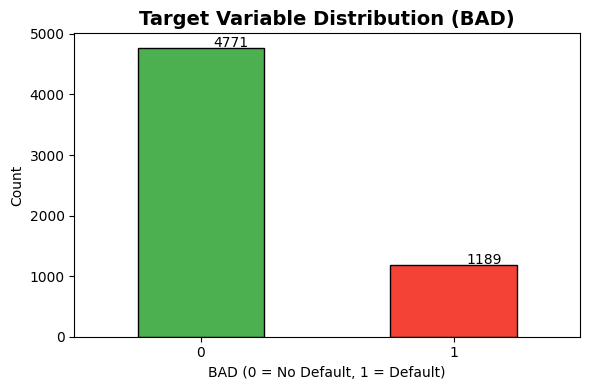

In [7]:
# --- Target Variable Distribution ---
print("🎯 Target Variable (BAD) Distribution:")
print(df['BAD'].value_counts())
print(f"\n% Defaulters: {df['BAD'].mean()*100:.2f}%")

plt.figure(figsize=(6, 4))
ax = df['BAD'].value_counts().plot(kind='bar', color=['#4CAF50', '#F44336'], edgecolor='black')
plt.title('Target Variable Distribution (BAD)', fontsize=14, fontweight='bold')
plt.xlabel('BAD (0 = No Default, 1 = Default)')
plt.ylabel('Count')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + 0.3, p.get_height() + 10))
plt.tight_layout()
plt.show()

# NOTE: If BAD=1 is much less than BAD=0, the dataset is IMBALANCED.
# We handle this with SMOTE in the preprocessing step.

🔴 Missing Values:
         Missing Count  Missing %
DEBTINC           1267  21.258389
DEROG              708  11.879195
DELINQ             580   9.731544
MORTDUE            518   8.691275
YOJ                515   8.640940
NINQ               510   8.557047
CLAGE              308   5.167785
JOB                279   4.681208
REASON             252   4.228188
CLNO               222   3.724832
VALUE              112   1.879195


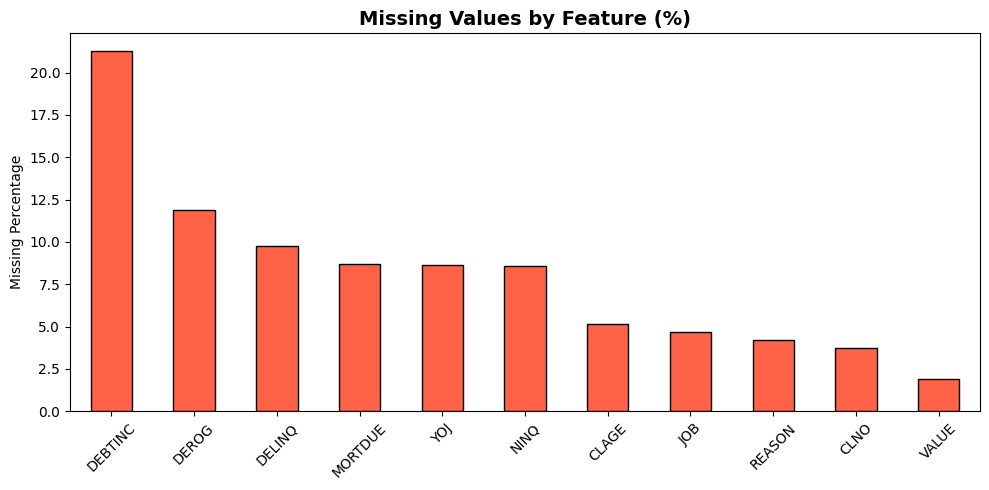

In [8]:
# --- Missing Values Analysis ---
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("🔴 Missing Values:")
print(missing_df)

plt.figure(figsize=(10, 5))
missing_pct[missing_pct > 0].sort_values(ascending=False).plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Missing Values by Feature (%)', fontsize=14, fontweight='bold')
plt.ylabel('Missing Percentage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

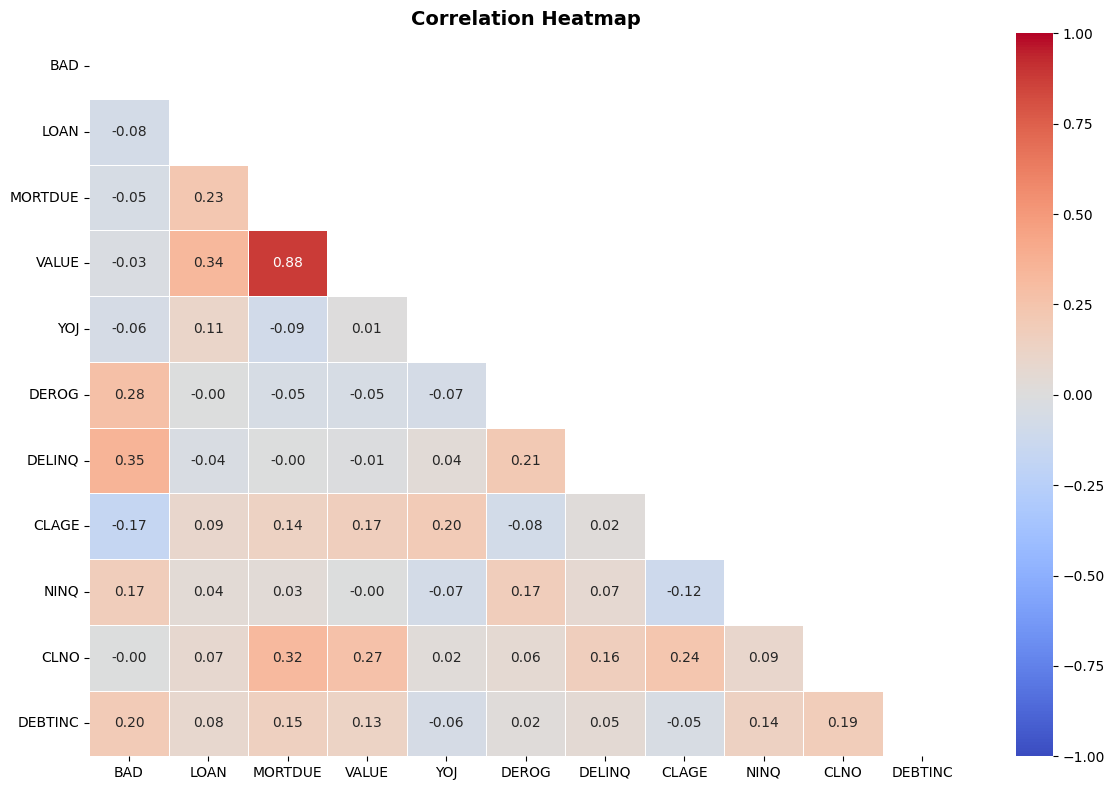

In [9]:
# --- Correlation Heatmap ---
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

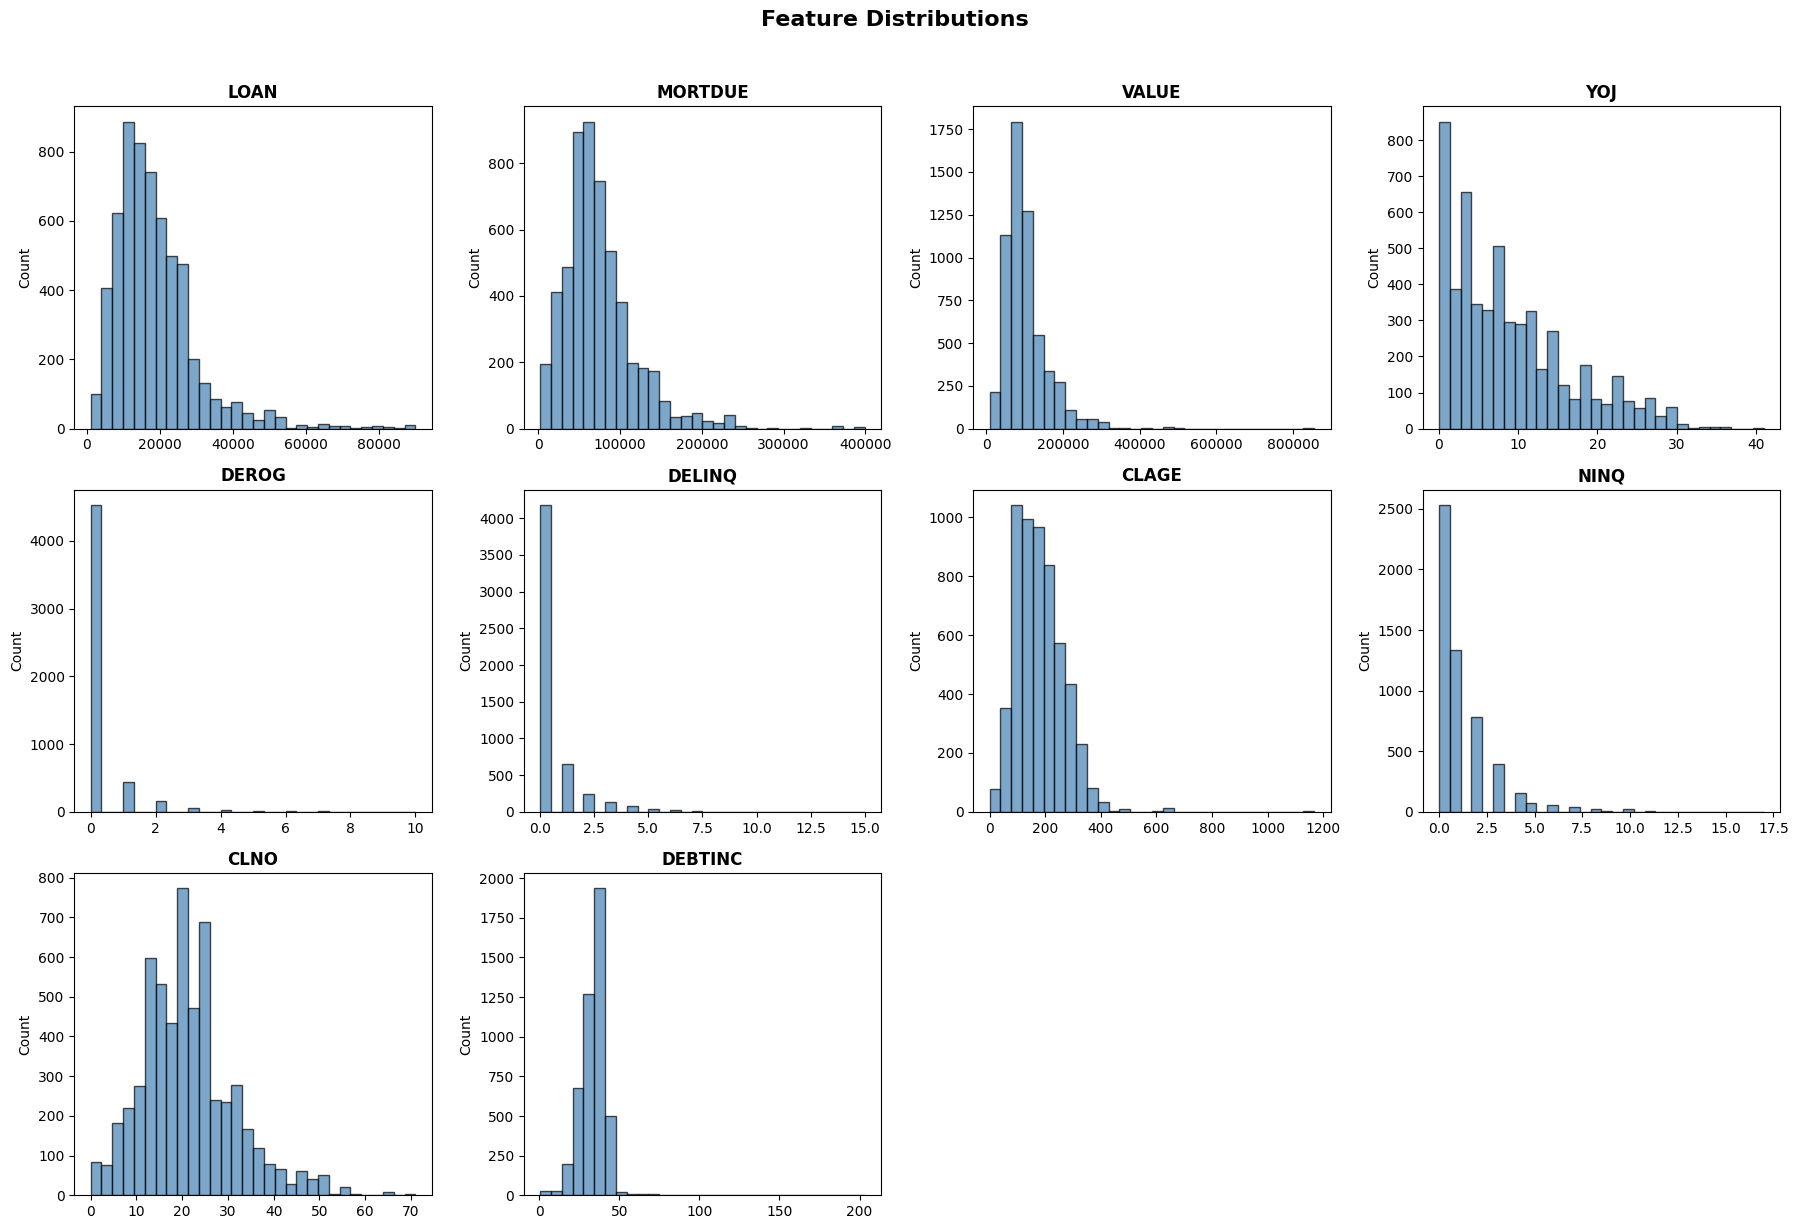

In [10]:
# --- Feature Distributions ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('BAD')

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Count')

# Hide any extra subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

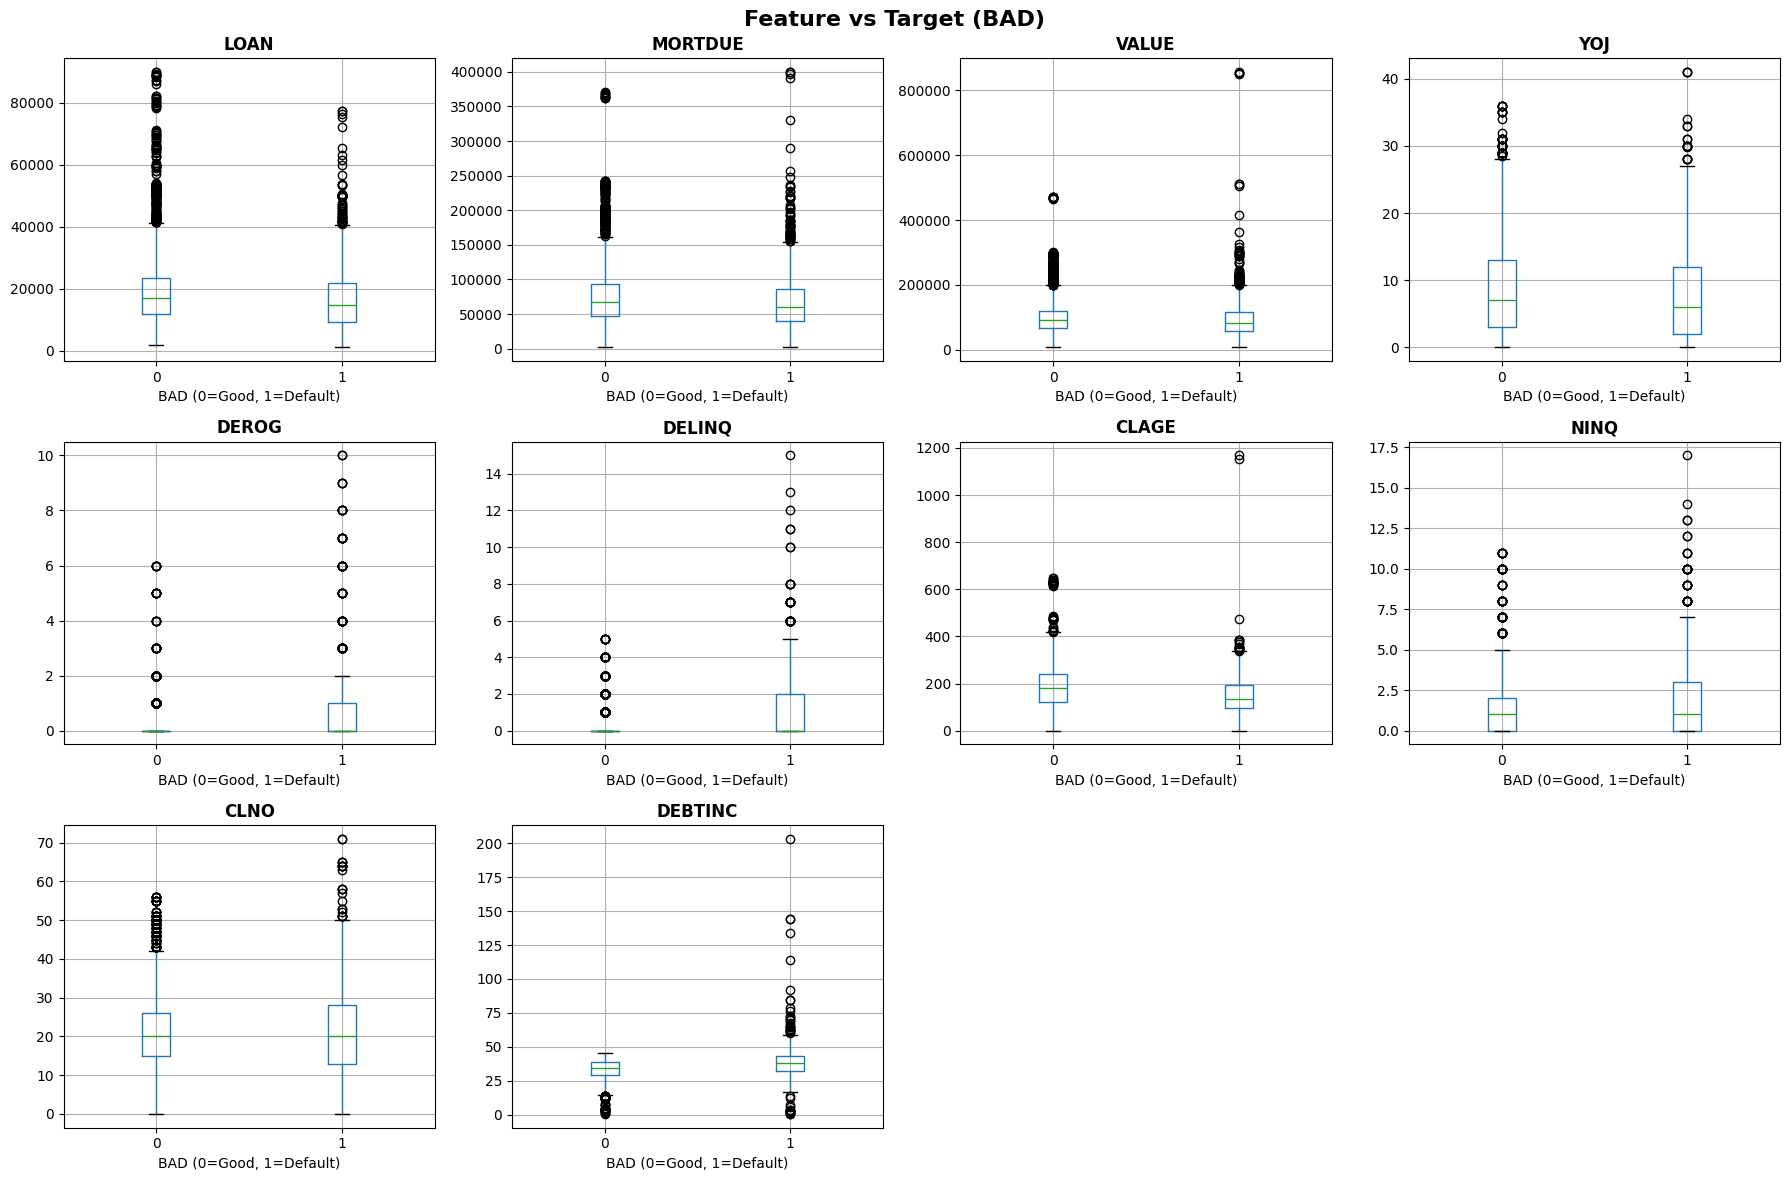

In [11]:
# --- Boxplots: Features vs Target ---
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    df.boxplot(column=col, by='BAD', ax=axes[i])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('BAD (0=Good, 1=Default)')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature vs Target (BAD)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# **Data Preprocessing**

In [12]:
# --- Step 4A: Handle Categorical Features ---
print("Categorical columns:", df.select_dtypes(include='object').columns.tolist())

# Encode categorical columns using Label Encoding
le = LabelEncoder()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("✅ Categorical encoding done.")

Categorical columns: ['REASON', 'JOB']
✅ Categorical encoding done.


In [13]:
# --- Step 4B: Handle Missing Values ---
# Separate features and target BEFORE imputation
X = df.drop('BAD', axis=1)
y = df['BAD']

# Impute numerical features with MEDIAN (robust to outliers)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f"✅ Missing values handled. Remaining nulls: {X_imputed.isnull().sum().sum()}")

✅ Missing values handled. Remaining nulls: 0


Before SMOTE - Class distribution:
BAD
0    4771
1    1189
Name: count, dtype: int64

After SMOTE - Class distribution:
BAD
1    4771
0    4771
Name: count, dtype: int64


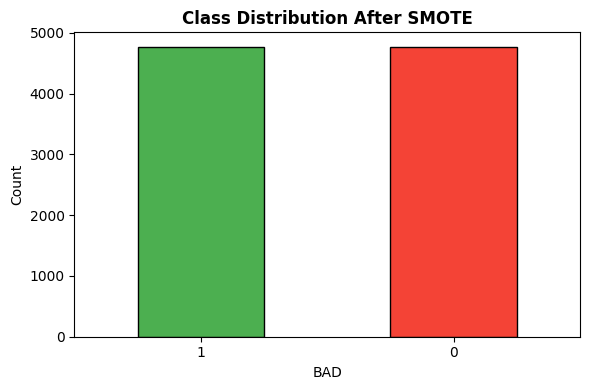

In [14]:
# --- Step 4C: Check & Handle Class Imbalance using SMOTE ---
print(f"Before SMOTE - Class distribution:\n{pd.Series(y).value_counts()}")

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_imputed, y)

print(f"\nAfter SMOTE - Class distribution:\n{pd.Series(y_resampled).value_counts()}")

# Visualize after SMOTE
plt.figure(figsize=(6, 4))
pd.Series(y_resampled).value_counts().plot(kind='bar', color=['#4CAF50', '#F44336'], edgecolor='black')
plt.title('Class Distribution After SMOTE', fontweight='bold')
plt.xlabel('BAD')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
# --- Step 4D: Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,
    stratify=y_resampled # preserve class ratio
)

print(f"✅ Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

✅ Train size: 7633 | Test size: 1909


In [16]:
# --- Step 4E: Feature Scaling (for Logistic Regression) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_scaled  = scaler.transform(X_test)         # transform test data

print("✅ Feature scaling done.")
print("Note: Random Forest does NOT need scaling. We use scaled data only for Logistic Regression.")

✅ Feature scaling done.
Note: Random Forest does NOT need scaling. We use scaled data only for Logistic Regression.


# **Model 1: Logistic Regression**

In [17]:
# --- Train ---
lr_model = LogisticRegression(
    max_iter=1000,      # enough iterations to converge
    random_state=42,
    class_weight='balanced'  # handles any residual imbalance
)
lr_model.fit(X_train_scaled, y_train)

# --- Predict ---
y_pred_lr     = lr_model.predict(X_test_scaled)
y_proba_lr    = lr_model.predict_proba(X_test_scaled)[:, 1]

# --- Metrics ---
print("=" * 55)
print("       LOGISTIC REGRESSION — EVALUATION RESULTS")
print("=" * 55)
print(f"\n✅ Accuracy  : {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print(f"✅ Precision : {precision_score(y_test, y_pred_lr)*100:.2f}%")
print(f"✅ Recall    : {recall_score(y_test, y_pred_lr)*100:.2f}%")
print(f"✅ F1-Score  : {f1_score(y_test, y_pred_lr)*100:.2f}%")
print(f"✅ ROC-AUC   : {roc_auc_score(y_test, y_proba_lr):.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Good (0)', 'Default (1)']))

       LOGISTIC REGRESSION — EVALUATION RESULTS

✅ Accuracy  : 73.13%
✅ Precision : 76.92%
✅ Recall    : 66.04%
✅ F1-Score  : 71.07%
✅ ROC-AUC   : 0.8198

📋 Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.70      0.80      0.75       955
 Default (1)       0.77      0.66      0.71       954

    accuracy                           0.73      1909
   macro avg       0.74      0.73      0.73      1909
weighted avg       0.74      0.73      0.73      1909



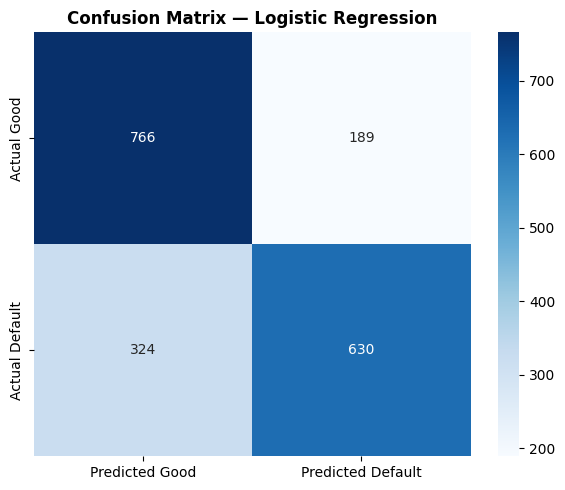

In [18]:
# --- Confusion Matrix for Logistic Regression ---
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Good', 'Predicted Default'],
            yticklabels=['Actual Good', 'Actual Default'])
plt.title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

# Explanation:
# True Negatives (TN): Correctly predicted "Good" → top-left
# False Positives (FP): Predicted "Default" but actually "Good" → top-right
# False Negatives (FN): Predicted "Good" but actually "Default" → bottom-left (COSTLY!)
# True Positives (TP): Correctly predicted "Default" → bottom-right

In [19]:
# --- Cross-Validation (to check for overfitting) ---
cv_scores_lr = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    X_resampled, y_resampled, cv=5, scoring='roc_auc'
)
print(f"\n🔁 5-Fold CV ROC-AUC (LR): {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")


🔁 5-Fold CV ROC-AUC (LR): 0.7729 ± 0.0654


# **Model 2: Random Forest Classifier**

In [20]:
# --- Train ---
rf_model = RandomForestClassifier(
    n_estimators=100,    # number of trees
    max_depth=None,      # let trees grow fully (we tune this later)
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)   # NO scaling needed for Random Forest

# --- Predict ---
y_pred_rf  = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# --- Metrics ---
print("=" * 55)
print("       RANDOM FOREST — EVALUATION RESULTS")
print("=" * 55)
print(f"\n✅ Accuracy  : {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"✅ Precision : {precision_score(y_test, y_pred_rf)*100:.2f}%")
print(f"✅ Recall    : {recall_score(y_test, y_pred_rf)*100:.2f}%")
print(f"✅ F1-Score  : {f1_score(y_test, y_pred_rf)*100:.2f}%")
print(f"✅ ROC-AUC   : {roc_auc_score(y_test, y_proba_rf):.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Good (0)', 'Default (1)']))

       RANDOM FOREST — EVALUATION RESULTS

✅ Accuracy  : 95.02%
✅ Precision : 96.33%
✅ Recall    : 93.61%
✅ F1-Score  : 94.95%
✅ ROC-AUC   : 0.9899

📋 Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.94      0.96      0.95       955
 Default (1)       0.96      0.94      0.95       954

    accuracy                           0.95      1909
   macro avg       0.95      0.95      0.95      1909
weighted avg       0.95      0.95      0.95      1909



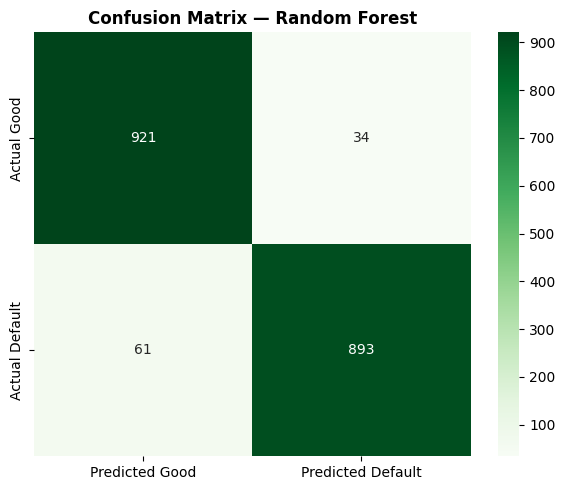

In [21]:
# --- Confusion Matrix for Random Forest ---
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Good', 'Predicted Default'],
            yticklabels=['Actual Good', 'Actual Default'])
plt.title('Confusion Matrix — Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# --- Cross-Validation for Random Forest ---
cv_scores_rf = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    X_resampled, y_resampled, cv=5, scoring='roc_auc'
)
print(f"\n🔁 5-Fold CV ROC-AUC (RF): {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")


🔁 5-Fold CV ROC-AUC (RF): 0.8188 ± 0.2245


# **ROC Curves (Both Models Together)**

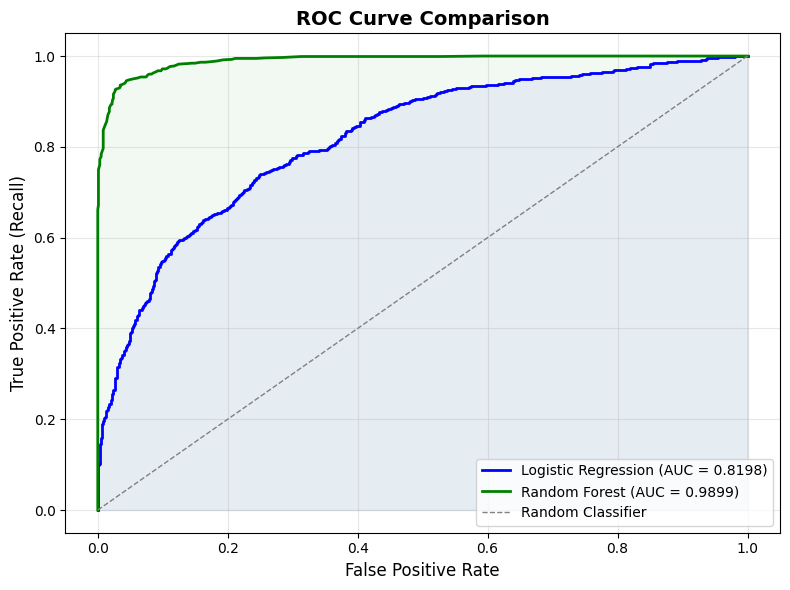

In [23]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='blue',   lw=2, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.4f})')
plt.plot(fpr_rf, tpr_rf, color='green',  lw=2, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.4f})')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.05, color='blue')
plt.fill_between(fpr_rf, tpr_rf, alpha=0.05, color='green')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation: The closer the curve hugs the top-left corner, the better the model.
# AUC closer to 1.0 = excellent; 0.5 = random guessing.

# **Hyperparameter Tuning (Random Forest with GridSearchCV)**

In [24]:
# Grid of parameters to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,       # use all CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# Use the best model
best_rf = grid_search.best_estimator_
y_pred_best_rf  = best_rf.predict(X_test)
y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

print(f"\n🔥 Tuned RF — Test ROC-AUC: {roc_auc_score(y_test, y_proba_best_rf):.4f}")
print(f"🔥 Tuned RF — Accuracy    : {accuracy_score(y_test, y_pred_best_rf)*100:.2f}%")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
✅ Best CV ROC-AUC: 0.9914

🔥 Tuned RF — Test ROC-AUC: 0.9904
🔥 Tuned RF — Accuracy    : 94.92%


# **Feature Importance (Random Forest)**

🏆 Top Features by Importance:
    Feature  Importance
7    DELINQ    0.185707
11  DEBTINC    0.152005
6     DEROG    0.101853
9      NINQ    0.096092
8     CLAGE    0.081558
2     VALUE    0.066886
0      LOAN    0.061648
1   MORTDUE    0.060672
10     CLNO    0.055927
5       YOJ    0.053175
4       JOB    0.043972
3    REASON    0.040504


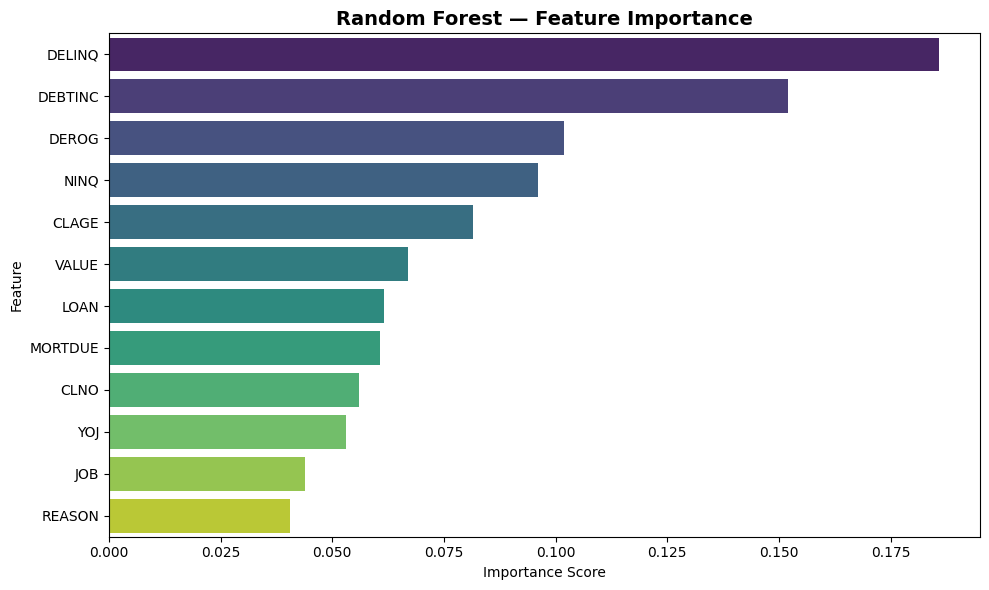

In [25]:
importances = best_rf.feature_importances_
feature_names = X.columns
feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("🏆 Top Features by Importance:")
print(feat_importance_df.head(12))

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Interpretation: Higher importance = the feature has more influence on predicting loan defaults.

# **Final Model Comparison Table**

In [26]:
results = {
    'Model': ['Logistic Regression', 'Random Forest (Default)', 'Random Forest (Tuned)'],
    'Accuracy (%)': [
        round(accuracy_score(y_test, y_pred_lr)*100, 2),
        round(accuracy_score(y_test, y_pred_rf)*100, 2),
        round(accuracy_score(y_test, y_pred_best_rf)*100, 2)
    ],
    'Precision (%)': [
        round(precision_score(y_test, y_pred_lr)*100, 2),
        round(precision_score(y_test, y_pred_rf)*100, 2),
        round(precision_score(y_test, y_pred_best_rf)*100, 2)
    ],
    'Recall (%)': [
        round(recall_score(y_test, y_pred_lr)*100, 2),
        round(recall_score(y_test, y_pred_rf)*100, 2),
        round(recall_score(y_test, y_pred_best_rf)*100, 2)
    ],
    'F1-Score (%)': [
        round(f1_score(y_test, y_pred_lr)*100, 2),
        round(f1_score(y_test, y_pred_rf)*100, 2),
        round(f1_score(y_test, y_pred_best_rf)*100, 2)
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, y_proba_lr), 4),
        round(roc_auc_score(y_test, y_proba_rf), 4),
        round(roc_auc_score(y_test, y_proba_best_rf), 4)
    ]
}

comparison_df = pd.DataFrame(results)
print("=" * 70)
print("            FINAL MODEL COMPARISON")
print("=" * 70)
print(comparison_df.to_string(index=False))

# Highlight best model
best_model_idx = comparison_df['ROC-AUC'].idxmax()
print(f"\n🏆 Best Model by ROC-AUC: {comparison_df.loc[best_model_idx, 'Model']}")

            FINAL MODEL COMPARISON
                  Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  ROC-AUC
    Logistic Regression         73.13          76.92       66.04         71.07   0.8198
Random Forest (Default)         95.02          96.33       93.61         94.95   0.9899
  Random Forest (Tuned)         94.92          96.03       93.71         94.85   0.9904

🏆 Best Model by ROC-AUC: Random Forest (Tuned)


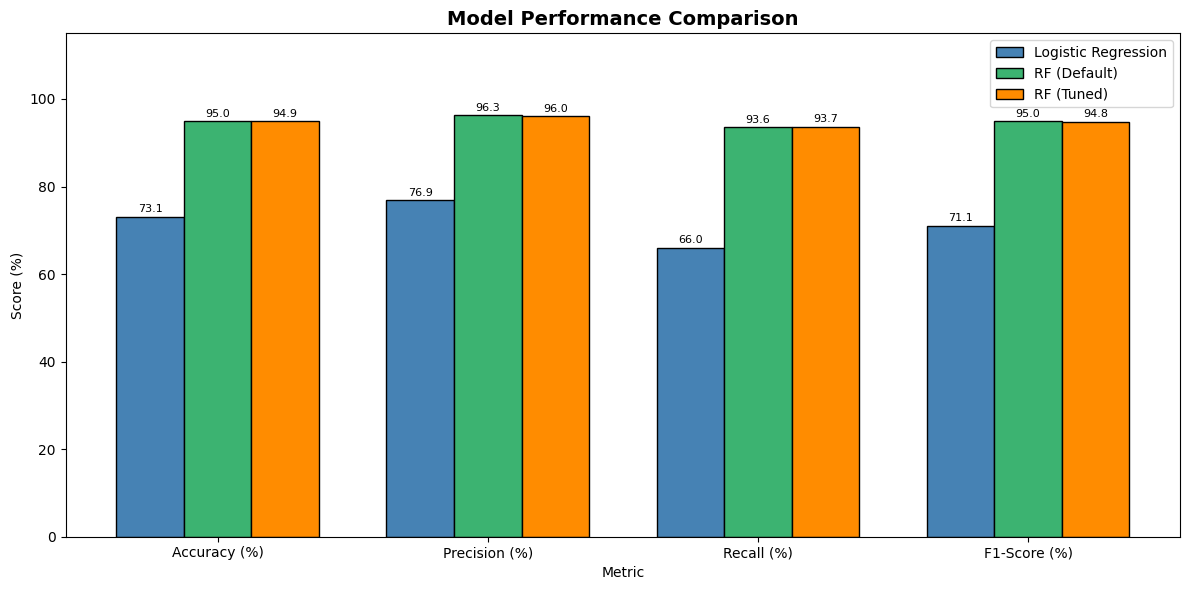

In [27]:
# --- Visual Comparison Bar Chart ---
metrics = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, comparison_df.loc[0, metrics], width, label='Logistic Regression', color='steelblue', edgecolor='black')
bars2 = ax.bar(x,         comparison_df.loc[1, metrics], width, label='RF (Default)',        color='mediumseagreen', edgecolor='black')
bars3 = ax.bar(x + width, comparison_df.loc[2, metrics], width, label='RF (Tuned)',          color='darkorange', edgecolor='black')

ax.set_xlabel('Metric')
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 115)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.1f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=8)
plt.tight_layout()
plt.show()

In [28]:
import joblib

# Save best model
joblib.dump(best_rf, 'best_rf_model.pkl')
joblib.dump(lr_model, 'lr_model.pkl')
joblib.dump(scaler,   'scaler.pkl')

# Save comparison table to CSV
comparison_df.to_csv('model_comparison.csv', index=False)
feat_importance_df.to_csv('feature_importance.csv', index=False)

print("✅ Models and results saved!")

# Download files to your computer
from google.colab import files
files.download('model_comparison.csv')
files.download('feature_importance.csv')

✅ Models and results saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
conclusion = f"""
CONCLUSION
==========
This project implemented and compared two supervised machine learning
algorithms — Logistic Regression and Random Forest — for credit risk
classification using the HMEQ dataset.

Key Findings:
--------------
- Logistic Regression achieved a test accuracy of {accuracy_score(y_test, y_pred_lr)*100:.2f}%
  and ROC-AUC of {roc_auc_score(y_test, y_proba_lr):.4f}. It is simple,
  interpretable, and fast, but may underperform on complex non-linear relationships.

- Random Forest (Tuned) achieved a test accuracy of {accuracy_score(y_test, y_pred_best_rf)*100:.2f}%
  and ROC-AUC of {roc_auc_score(y_test, y_proba_best_rf):.4f}. It captured
  complex feature interactions and showed superior overall performance.

- Top predictive features: {', '.join(feat_importance_df['Feature'].head(3).tolist())}

- Class imbalance was addressed using SMOTE oversampling.

- Hyperparameter tuning via GridSearchCV improved the Random Forest model.

Best Model: {'Random Forest (Tuned)' if roc_auc_score(y_test, y_proba_best_rf) > roc_auc_score(y_test, y_proba_lr) else 'Logistic Regression'}
Recommendation: Use Random Forest for production due to higher accuracy
and AUC, while Logistic Regression remains useful for interpretability
and regulatory explainability in banking contexts.
"""

print(conclusion)


CONCLUSION
This project implemented and compared two supervised machine learning
algorithms — Logistic Regression and Random Forest — for credit risk
classification using the HMEQ dataset.

Key Findings:
--------------
- Logistic Regression achieved a test accuracy of 73.13%
  and ROC-AUC of 0.8198. It is simple,
  interpretable, and fast, but may underperform on complex non-linear relationships.

- Random Forest (Tuned) achieved a test accuracy of 94.92%
  and ROC-AUC of 0.9904. It captured
  complex feature interactions and showed superior overall performance.

- Top predictive features: DELINQ, DEBTINC, DEROG

- Class imbalance was addressed using SMOTE oversampling.

- Hyperparameter tuning via GridSearchCV improved the Random Forest model.

Best Model: Random Forest (Tuned)
Recommendation: Use Random Forest for production due to higher accuracy
and AUC, while Logistic Regression remains useful for interpretability
and regulatory explainability in banking contexts.



# **Save Models**

In [30]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Save the best model and imputer
joblib.dump(best_rf, 'best_rf_model.pkl')
joblib.dump(imputer, 'imputer.pkl')

# Fix: use 'df' not 'df_original'
le_reason = LabelEncoder()
le_reason.fit(df['REASON'].astype(str))
joblib.dump(le_reason, 'le_reason.pkl')

le_job = LabelEncoder()
le_job.fit(df['JOB'].astype(str))
joblib.dump(le_job, 'le_job.pkl')

print("✅ Saved: best_rf_model.pkl, imputer.pkl, le_reason.pkl, le_job.pkl")

# Download all 4 files
from google.colab import files
for fname in ['best_rf_model.pkl', 'imputer.pkl', 'le_reason.pkl', 'le_job.pkl']:
    files.download(fname)

✅ Saved: best_rf_model.pkl, imputer.pkl, le_reason.pkl, le_job.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>